# mmraz-qwen3-32b-probe-variations-question-only-plots

Small plotting notebook for the Qwen3-32B **question-only** probe-variation runs.

It:
- finds the latest compatible Qwen3-32B question-only probe-training run by default,
- loads the saved metrics / summary / metadata,
- reproduces the same replot structure used for the Qwen3-4B probe notebook, adapted to the 32B question-level split setup, and
- saves the replotted figures under a `replots_from_notebook/` subdirectory inside the selected run folder.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
plt.rcParams['lines.markersize'] = 5

REQUIRED_ARTIFACT_FORMAT_VERSION = 1
RUN_DIR_OVERRIDE = globals().get('RUN_DIR_OVERRIDE', None)


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists() and (candidate / 'results').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from current working directory.')


def resolve_primary_artifacts(run_dir: Path):
    run_id = run_dir.name
    candidates = [
        {
            'metrics_path': run_dir / f'qwen3_32b_question_only_probe_metrics_{run_id}.csv',
            'summary_path': run_dir / f'qwen3_32b_question_only_probe_summary_{run_id}.csv',
            'artifact_path': run_dir / f'qwen3_32b_question_only_probe_artifacts_{run_id}.npz',
            'metadata_path': run_dir / f'qwen3_32b_question_only_probe_metadata_{run_id}.json',
            'figure_index_path': run_dir / f'qwen3_32b_question_only_probe_figures_{run_id}.csv',
            'selected_stage': 'final_all_regimes',
        },
        {
            'metrics_path': run_dir / f'qwen3_32b_question_only_probe_metrics_{run_id}_explicit_only_checkpoint.csv',
            'summary_path': run_dir / f'qwen3_32b_question_only_probe_summary_{run_id}_explicit_only_checkpoint.csv',
            'artifact_path': run_dir / f'qwen3_32b_question_only_probe_artifacts_{run_id}_explicit_only_checkpoint.npz',
            'metadata_path': run_dir / f'qwen3_32b_question_only_probe_metadata_{run_id}_explicit_only_checkpoint.json',
            'figure_index_path': run_dir / f'qwen3_32b_question_only_probe_figures_{run_id}_explicit_only_checkpoint.csv',
            'selected_stage': 'explicit_only_checkpoint',
        },
        {
            'metrics_path': run_dir / f'qwen3_32b_question_only_probe_metrics_{run_id}_implicit_only_checkpoint.csv',
            'summary_path': run_dir / f'qwen3_32b_question_only_probe_summary_{run_id}_implicit_only_checkpoint.csv',
            'artifact_path': run_dir / f'qwen3_32b_question_only_probe_artifacts_{run_id}_implicit_only_checkpoint.npz',
            'metadata_path': run_dir / f'qwen3_32b_question_only_probe_metadata_{run_id}_implicit_only_checkpoint.json',
            'figure_index_path': run_dir / f'qwen3_32b_question_only_probe_figures_{run_id}_implicit_only_checkpoint.csv',
            'selected_stage': 'implicit_only_checkpoint',
        },
    ]
    for artifact_set in candidates:
        required = [artifact_set['metrics_path'], artifact_set['summary_path'], artifact_set['artifact_path'], artifact_set['metadata_path']]
        if all(path.exists() for path in required):
            if not artifact_set['figure_index_path'].exists():
                artifact_set['figure_index_path'] = None
            return artifact_set

    metadata_candidates = sorted(run_dir.glob('qwen3_32b_question_only_probe_metadata_*.json'))
    metrics_candidates = sorted(run_dir.glob('qwen3_32b_question_only_probe_metrics_*.csv'))
    summary_candidates = sorted(run_dir.glob('qwen3_32b_question_only_probe_summary_*.csv'))
    artifact_candidates = sorted(run_dir.glob('qwen3_32b_question_only_probe_artifacts_*.npz'))
    figure_candidates = sorted(run_dir.glob('qwen3_32b_question_only_probe_figures_*.csv'))
    if not metadata_candidates or not metrics_candidates or not summary_candidates or not artifact_candidates:
        raise FileNotFoundError(f'Missing question-only artifact files in run dir: {run_dir}')
    return {
        'metrics_path': metrics_candidates[-1],
        'summary_path': summary_candidates[-1],
        'artifact_path': artifact_candidates[-1],
        'metadata_path': metadata_candidates[-1],
        'figure_index_path': figure_candidates[-1] if figure_candidates else None,
        'selected_stage': 'auto_latest_match',
    }


def metadata_is_compatible(metadata: dict) -> bool:
    if int(metadata.get('artifact_format_version', 0)) < REQUIRED_ARTIFACT_FORMAT_VERSION:
        return False
    if metadata.get('prompt_family') != 'question_only_teacher_forced_answers':
        return False
    if metadata.get('explicit_split_granularity') != 'question':
        return False
    if metadata.get('implicit_split_granularity') != 'question':
        return False
    if not bool(metadata.get('probe_prompt_use_chat_template', metadata.get('use_chat_template', False))):
        return False
    if not bool(metadata.get('probe_prompt_disable_thinking_trace', metadata.get('disable_thinking_trace', False))):
        return False
    return True


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results' / 'qwen3_32b' / 'question_only_probe_variations'
RUN_AVAILABLE = False
RUN_DIR = None
artifacts = None
metadata = {}
metrics_df = pd.DataFrame()
summary_df = pd.DataFrame()
figure_index_df = pd.DataFrame()

candidate_runs = []
if RUN_DIR_OVERRIDE is not None:
    run_dir = Path(RUN_DIR_OVERRIDE).expanduser().resolve()
    artifact_set = resolve_primary_artifacts(run_dir)
    metadata_payload = json.loads(artifact_set['metadata_path'].read_text(encoding='utf-8'))
    if not metadata_is_compatible(metadata_payload):
        raise RuntimeError(f'Run override is not compatible with this notebook: {run_dir}')
    candidate_runs.append((run_dir, artifact_set, metadata_payload))
elif RESULTS_ROOT.exists():
    for run_dir in sorted(path for path in RESULTS_ROOT.iterdir() if path.is_dir()):
        try:
            artifact_set = resolve_primary_artifacts(run_dir)
        except FileNotFoundError:
            continue
        metadata_payload = json.loads(artifact_set['metadata_path'].read_text(encoding='utf-8'))
        if metadata_is_compatible(metadata_payload):
            candidate_runs.append((run_dir, artifact_set, metadata_payload))

if candidate_runs:
    RUN_DIR, artifacts, metadata = candidate_runs[-1]
    metrics_df = pd.read_csv(artifacts['metrics_path'])
    summary_df = pd.read_csv(artifacts['summary_path'])
    if artifacts['figure_index_path'] is not None and artifacts['figure_index_path'].exists():
        figure_index_df = pd.read_csv(artifacts['figure_index_path'])
    RUN_AVAILABLE = True

if RUN_AVAILABLE:
    print('Repo root        :', ROOT)
    print('Results root     :', RESULTS_ROOT)
    print('Selected run     :', RUN_DIR.name)
    print('Selected stage   :', artifacts['selected_stage'])
    print('Metrics path     :', artifacts['metrics_path'])
    print('Summary path     :', artifacts['summary_path'])
    print('Metadata path    :', artifacts['metadata_path'])
    display(pd.DataFrame([
        {'kind': 'metrics_csv', 'path': str(artifacts['metrics_path'])},
        {'kind': 'summary_csv', 'path': str(artifacts['summary_path'])},
        {'kind': 'artifact_npz', 'path': str(artifacts['artifact_path'])},
        {'kind': 'metadata_json', 'path': str(artifacts['metadata_path'])},
        {'kind': 'figure_index_csv', 'path': str(artifacts['figure_index_path']) if artifacts['figure_index_path'] else ''},
    ]))
    display(summary_df)
else:
    print('No compatible Qwen3-32B question-only probe run found under:', RESULTS_ROOT)
    print('Run the 32B training script first, or set RUN_DIR_OVERRIDE to a specific run directory.')


Repo root        : /Users/michalmraz/code/spar-ai/temporal-awareness
Results root     : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations
Selected run     : 20260410-093720
Selected stage   : final_all_regimes
Metrics path     : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations/20260410-093720/qwen3_32b_question_only_probe_metrics_20260410-093720.csv
Summary path     : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations/20260410-093720/qwen3_32b_question_only_probe_summary_20260410-093720.csv
Metadata path    : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations/20260410-093720/qwen3_32b_question_only_probe_metadata_20260410-093720.json


,kind,path
0,metrics_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,summary_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,artifact_npz,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,metadata_json,/Users/michalmraz/code/spar-ai/temporal-awaren...
4,figure_index_csv,/Users/michalmraz/code/spar-ai/temporal-awaren...


,train_dataset,train_dataset_label,train_domain,cross_domain,feature_name,best_lr_in_domain_holdout_acc_layer,best_lr_in_domain_holdout_acc,best_lr_cross_domain_holdout_acc_layer,best_lr_cross_domain_holdout_acc,best_lr_explicit_full_acc_layer,...,best_mm_implicit_full_acc_layer,best_mm_implicit_full_acc,best_wmm_in_domain_holdout_acc_layer,best_wmm_in_domain_holdout_acc,best_wmm_cross_domain_holdout_acc_layer,best_wmm_cross_domain_holdout_acc,best_wmm_explicit_full_acc_layer,best_wmm_explicit_full_acc,best_wmm_implicit_full_acc_layer,best_wmm_implicit_full_acc
0,explicit_train_only,explicit train only,explicit,implicit,last_answer_token,24,0.995000,40,0.827778,24,...,24,0.743333,24,0.995000,40,0.827778,24,0.999,48,0.826667
1,explicit_train_only,explicit train only,explicit,implicit,mean_answer_tokens,28,0.990000,24,0.800000,28,...,32,0.770000,32,0.990000,28,0.788889,32,0.998,28,0.803333
2,implicit_train_only,implicit train only,implicit,explicit,last_answer_token,28,0.983333,40,0.860000,40,...,48,0.855000,28,0.972222,36,0.875000,36,0.896,28,0.991667
3,implicit_train_only,implicit train only,implicit,explicit,mean_answer_tokens,32,0.988889,40,0.910000,44,...,40,0.811667,44,0.977778,36,0.875000,24,0.869,44,0.993333


In [2]:
PROBE_FAMILIES = ['lr', 'wlr', 'mm', 'wmm']
STYLE_LAST_ONLY = {
    'lr': {'label': 'LR', 'color': 'C0', 'marker': 'o'},
    'wlr': {'label': 'WLR', 'color': 'C1', 'marker': 'o'},
    'mm': {'label': 'MM', 'color': 'C2', 'marker': 'o'},
    'wmm': {'label': 'WMM', 'color': 'C3', 'marker': 'o'},
}
STYLE_MEAN_ONLY = STYLE_LAST_ONLY
STYLE_COMPARISON = {
    'lr': {
        'last': {'color': 'C0', 'marker': 'o', 'linestyle': '-', 'label': 'LR, last answer token'},
        'mean': {'color': 'C0', 'marker': 'o', 'linestyle': '--', 'label': 'LR, mean answer tokens'},
    },
    'wlr': {
        'last': {'color': 'C1', 'marker': 'o', 'linestyle': '-', 'label': 'WLR, last answer token'},
        'mean': {'color': 'C1', 'marker': 'o', 'linestyle': '--', 'label': 'WLR, mean answer tokens'},
    },
    'mm': {
        'last': {'color': 'C2', 'marker': 'o', 'linestyle': '-', 'label': 'MM, last answer token'},
        'mean': {'color': 'C2', 'marker': 'o', 'linestyle': '--', 'label': 'MM, mean answer tokens'},
    },
    'wmm': {
        'last': {'color': 'C3', 'marker': 'o', 'linestyle': '-', 'label': 'WMM, last answer token'},
        'mean': {'color': 'C3', 'marker': 'o', 'linestyle': '--', 'label': 'WMM, mean answer tokens'},
    },
}


def add_line_only_legend(ax, *, loc='lower left', fontsize=8, ncol=1):
    from matplotlib.lines import Line2D

    handles, labels = ax.get_legend_handles_labels()
    line_only_handles = [
        Line2D([0], [0], color=handle.get_color(), linestyle=handle.get_linestyle(), linewidth=handle.get_linewidth())
        for handle in handles
    ]
    ax.legend(line_only_handles, labels, loc=loc, fontsize=fontsize, ncol=ncol)


def set_trained_layer_ticks(ax, layers):
    trained_layers = sorted({int(layer) for layer in layers})
    ax.set_xticks(trained_layers)
    ax.set_xticklabels([str(layer) for layer in trained_layers])
    if len(trained_layers) > 1:
        min_step = min(
            next_layer - layer
            for layer, next_layer in zip(trained_layers, trained_layers[1:])
        )
        pad = min_step / 2
    else:
        pad = 0.5
    ax.set_xlim(trained_layers[0] - pad, trained_layers[-1] + pad)


def draw_pooling_only_figure(df, title_prefix, style_map):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    trained_layers = df['layer'].tolist()
    for ax, metric, title in [
        (axes[0], 'in_domain_holdout_acc', 'In-domain held-out accuracy by layer'),
        (axes[1], 'cross_domain_holdout_acc', 'Cross-domain held-out accuracy by layer'),
    ]:
        for family in PROBE_FAMILIES:
            style = style_map[family]
            ax.plot(
                df['layer'],
                df[f'{family}_{metric}'],
                marker=style['marker'],
                linewidth=2,
                color=style['color'],
                label=style['label'],
            )
        ax.set_title(title)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.45, 1.02)
        set_trained_layer_ticks(ax, trained_layers)
        ax.grid(True, alpha=0.3)
        add_line_only_legend(ax, loc='lower left', fontsize=8)
    fig.suptitle(title_prefix, y=1.03)
    return fig


def draw_comparison_figure(last_df, mean_df, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    trained_layers = sorted(set(last_df['layer']).union(set(mean_df['layer'])))
    for ax, metric, title in [
        (axes[0], 'in_domain_holdout_acc', 'In-domain held-out accuracy by layer'),
        (axes[1], 'cross_domain_holdout_acc', 'Cross-domain held-out accuracy by layer'),
    ]:
        for family in PROBE_FAMILIES:
            last_style = STYLE_COMPARISON[family]['last']
            mean_style = STYLE_COMPARISON[family]['mean']
            ax.plot(
                last_df['layer'],
                last_df[f'{family}_{metric}'],
                linewidth=2,
                marker=last_style['marker'],
                linestyle=last_style['linestyle'],
                color=last_style['color'],
                label=last_style['label'],
            )
            ax.plot(
                mean_df['layer'],
                mean_df[f'{family}_{metric}'],
                linewidth=2,
                marker=mean_style['marker'],
                linestyle=mean_style['linestyle'],
                color=mean_style['color'],
                label=mean_style['label'],
            )
        ax.set_title(title)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0.45, 1.02)
        set_trained_layer_ticks(ax, trained_layers)
        ax.grid(True, alpha=0.3)
        add_line_only_legend(ax, loc='lower left', fontsize=8, ncol=2)
    fig.suptitle(title_prefix, y=1.03)
    return fig


,train_dataset,train_dataset_label,train_domain,cross_domain,feature_name,best_lr_in_domain_holdout_acc_layer,best_lr_in_domain_holdout_acc,best_lr_cross_domain_holdout_acc_layer,best_lr_cross_domain_holdout_acc,best_lr_explicit_full_acc_layer,...,best_mm_implicit_full_acc_layer,best_mm_implicit_full_acc,best_wmm_in_domain_holdout_acc_layer,best_wmm_in_domain_holdout_acc,best_wmm_cross_domain_holdout_acc_layer,best_wmm_cross_domain_holdout_acc,best_wmm_explicit_full_acc_layer,best_wmm_explicit_full_acc,best_wmm_implicit_full_acc_layer,best_wmm_implicit_full_acc
0,explicit_train_only,explicit train only,explicit,implicit,last_answer_token,24,0.995000,40,0.827778,24,...,24,0.743333,24,0.995000,40,0.827778,24,0.999,48,0.826667
1,explicit_train_only,explicit train only,explicit,implicit,mean_answer_tokens,28,0.990000,24,0.800000,28,...,32,0.770000,32,0.990000,28,0.788889,32,0.998,28,0.803333
2,implicit_train_only,implicit train only,implicit,explicit,last_answer_token,28,0.983333,40,0.860000,40,...,48,0.855000,28,0.972222,36,0.875000,36,0.896,28,0.991667
3,implicit_train_only,implicit train only,implicit,explicit,mean_answer_tokens,32,0.988889,40,0.910000,44,...,40,0.811667,44,0.977778,36,0.875000,24,0.869,44,0.993333


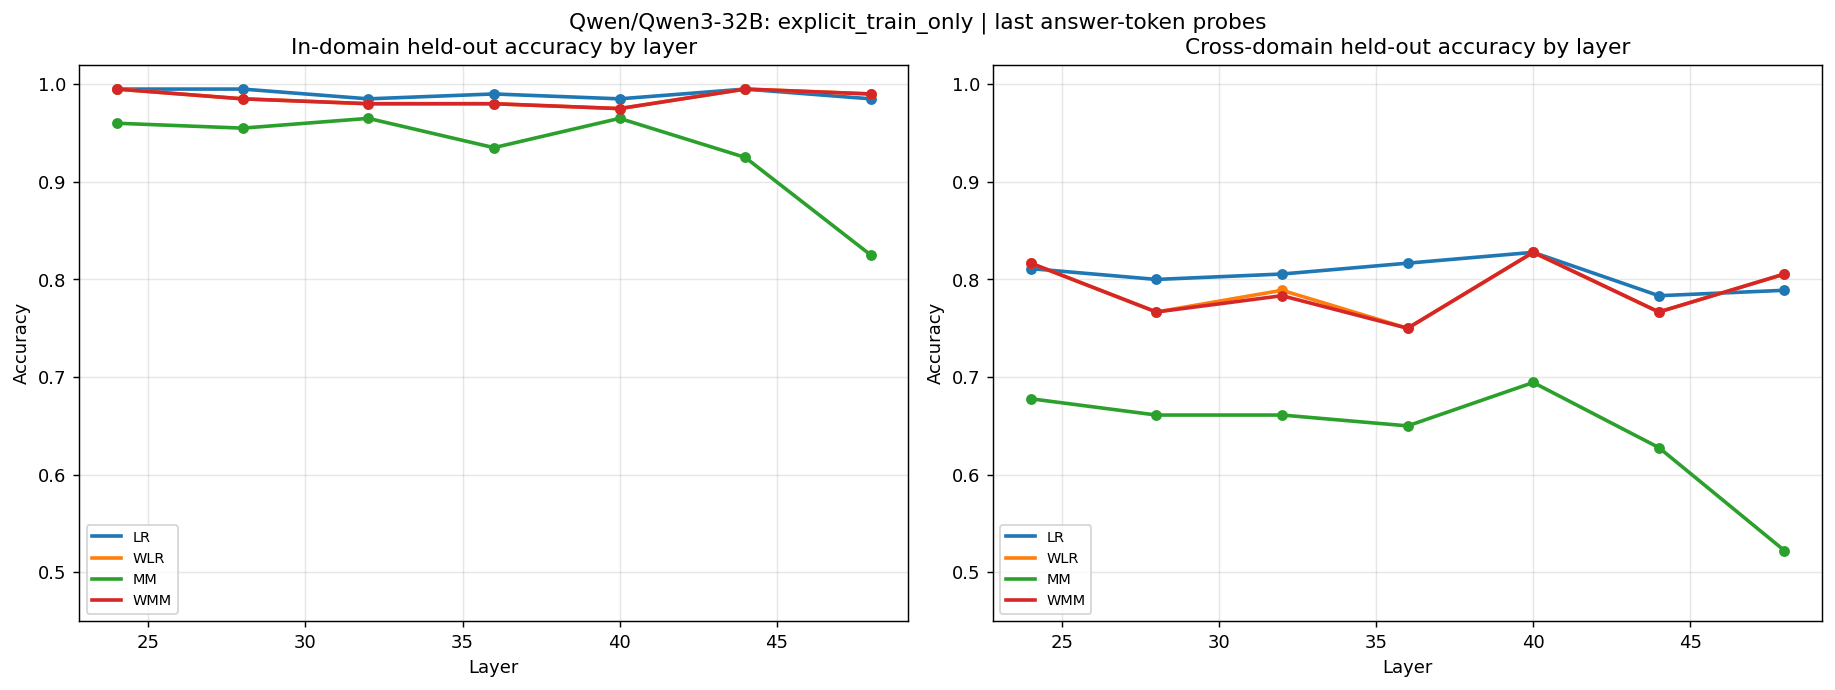

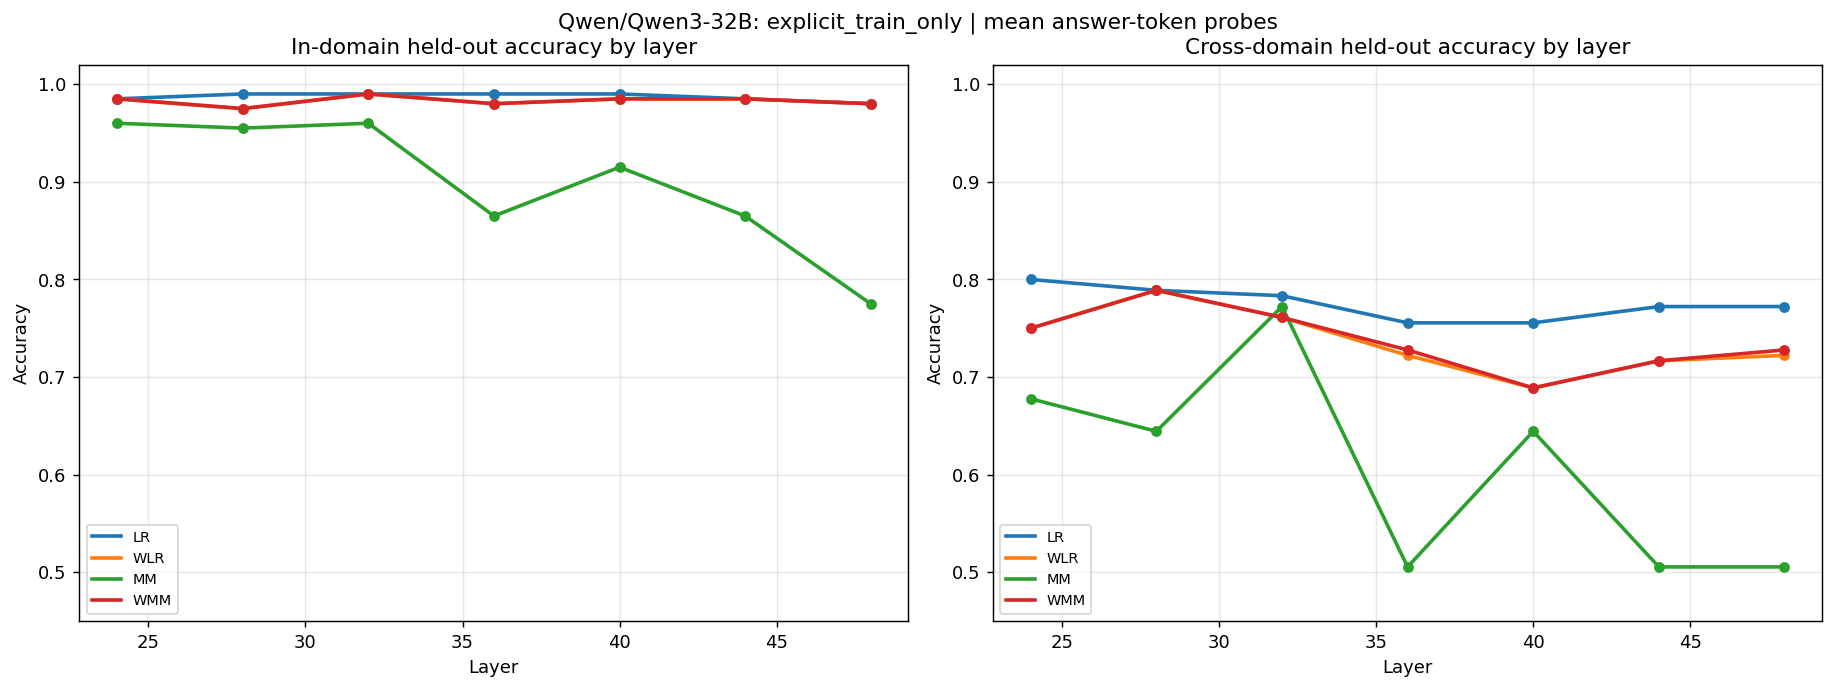

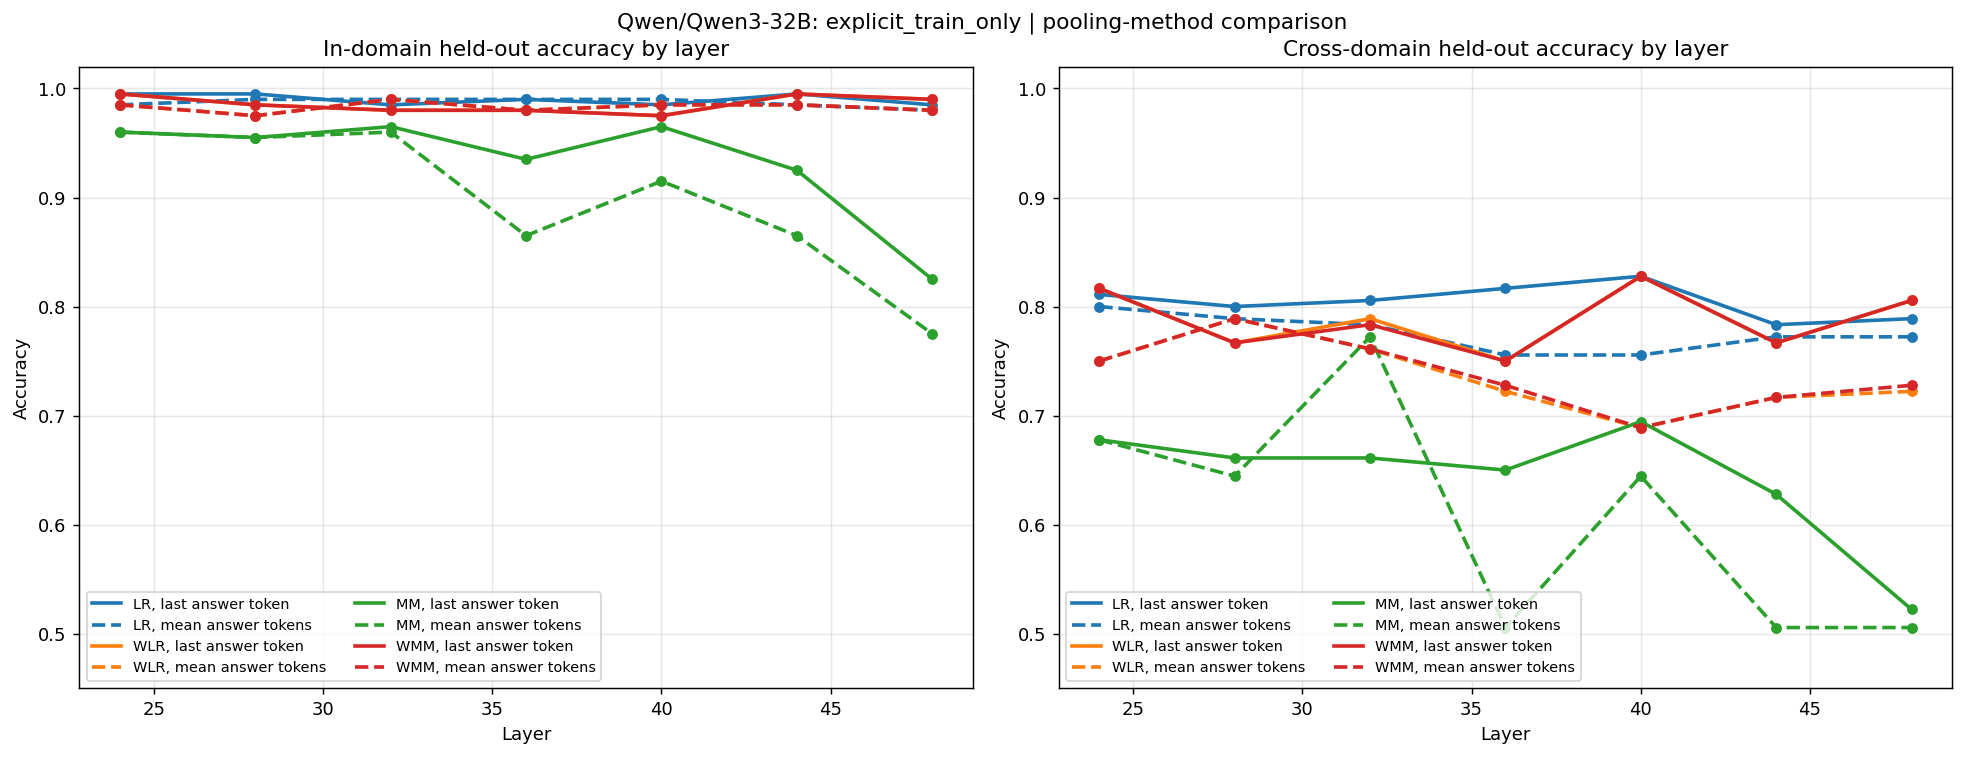

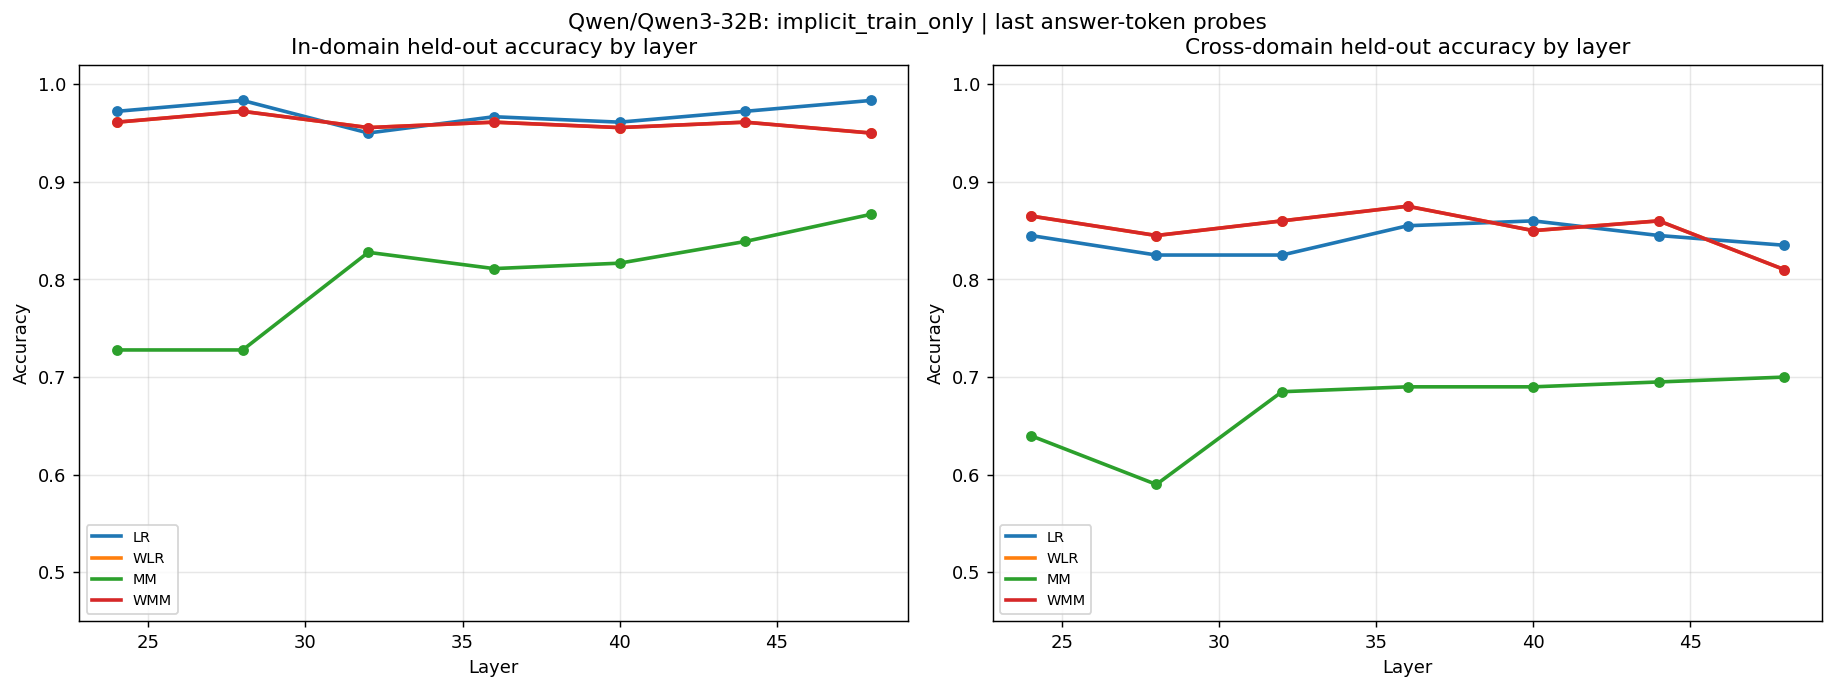

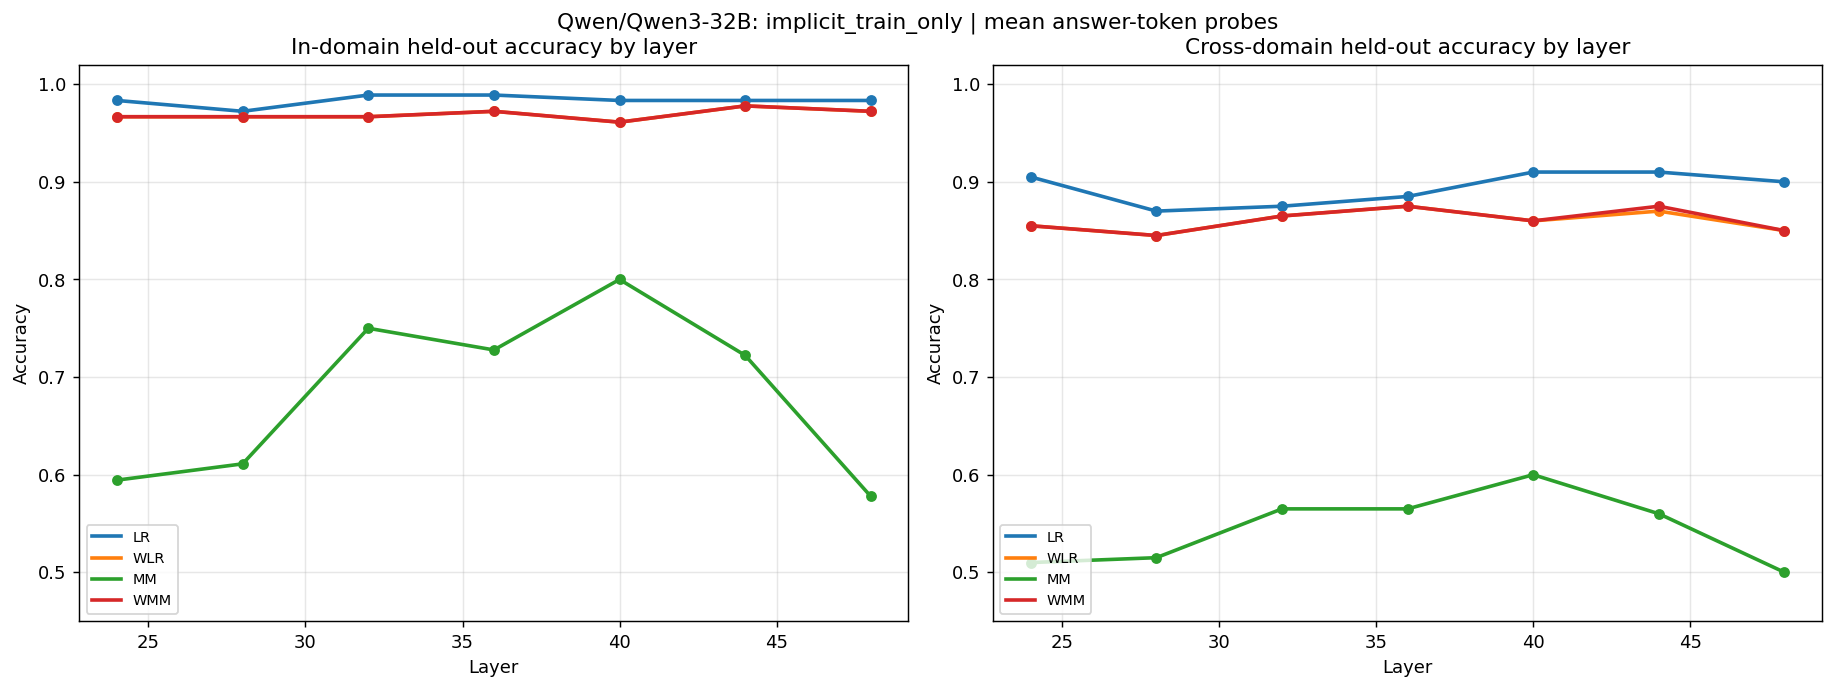

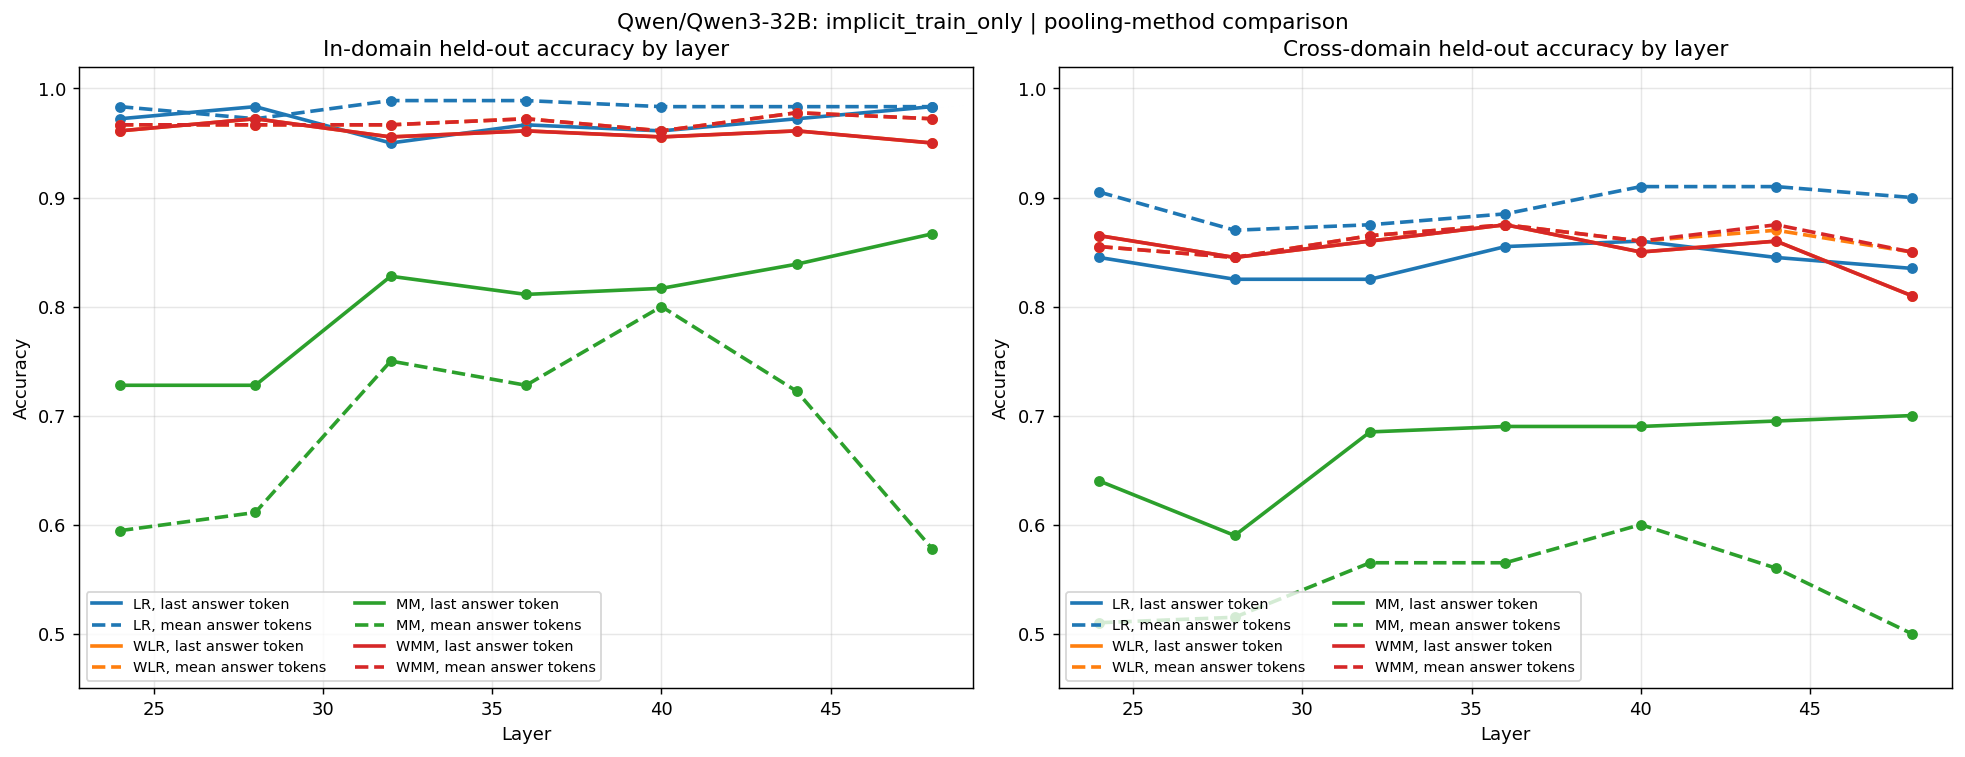

Saved replots in: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations/20260410-093720/replots_from_notebook
Saved replot index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_32b/question_only_probe_variations/20260410-093720/replots_from_notebook/qwen3_32b_question_only_probe_replots.csv
No red-team comparison panel is included here because the 32B setup currently saves only explicit-train-only and implicit-train-only regimes.


,train_dataset,figure_type,path
0,explicit_train_only,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,explicit_train_only,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,explicit_train_only,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,implicit_train_only,last_answer_token,/Users/michalmraz/code/spar-ai/temporal-awaren...
4,implicit_train_only,mean_answer_tokens,/Users/michalmraz/code/spar-ai/temporal-awaren...
5,implicit_train_only,comparison,/Users/michalmraz/code/spar-ai/temporal-awaren...


In [3]:
if not RUN_AVAILABLE:
    print('Skipping replots because no compatible Qwen3-32B probe run was found.')
else:
    REPLOT_DIR = RUN_DIR / 'replots_from_notebook'
    REPLOT_DIR.mkdir(parents=True, exist_ok=True)

    regime_results = {}
    train_regimes = metadata.get('train_regimes', metrics_df['train_dataset'].drop_duplicates().tolist())
    feature_names = metadata.get('feature_names', metrics_df['feature_name'].drop_duplicates().tolist())
    for train_dataset in train_regimes:
        regime_results[train_dataset] = {}
        for feature_name in feature_names:
            subset = (
                metrics_df[
                    (metrics_df['train_dataset'] == train_dataset)
                    & (metrics_df['feature_name'] == feature_name)
                ]
                .sort_values('layer')
                .reset_index(drop=True)
            )
            if len(subset):
                regime_results[train_dataset][feature_name] = subset

    display(summary_df)

    replot_rows = []
    for regime_name, feature_map in regime_results.items():
        if 'last_answer_token' not in feature_map or 'mean_answer_tokens' not in feature_map:
            print(f'Skipping {regime_name}: missing one of last_answer_token / mean_answer_tokens.')
            continue
        safe_regime_name = regime_name.replace('/', '_')
        last_df = feature_map['last_answer_token']
        mean_df = feature_map['mean_answer_tokens']

        last_fig = draw_pooling_only_figure(
            last_df,
            f"{metadata['model_name']}: {regime_name} | last answer-token probes",
            STYLE_LAST_ONLY,
        )
        mean_fig = draw_pooling_only_figure(
            mean_df,
            f"{metadata['model_name']}: {regime_name} | mean answer-token probes",
            STYLE_MEAN_ONLY,
        )
        comparison_fig = draw_comparison_figure(
            last_df,
            mean_df,
            f"{metadata['model_name']}: {regime_name} | pooling-method comparison",
        )

        last_fig_path = REPLOT_DIR / f'{safe_regime_name}_last_answer_token_replot.png'
        mean_fig_path = REPLOT_DIR / f'{safe_regime_name}_mean_answer_tokens_replot.png'
        comparison_fig_path = REPLOT_DIR / f'{safe_regime_name}_comparison_replot.png'

        last_fig.savefig(last_fig_path, dpi=200, bbox_inches='tight')
        mean_fig.savefig(mean_fig_path, dpi=200, bbox_inches='tight')
        comparison_fig.savefig(comparison_fig_path, dpi=200, bbox_inches='tight')

        display(last_fig)
        display(mean_fig)
        display(comparison_fig)
        plt.close(last_fig)
        plt.close(mean_fig)
        plt.close(comparison_fig)

        replot_rows.extend([
            {'train_dataset': regime_name, 'figure_type': 'last_answer_token', 'path': str(last_fig_path)},
            {'train_dataset': regime_name, 'figure_type': 'mean_answer_tokens', 'path': str(mean_fig_path)},
            {'train_dataset': regime_name, 'figure_type': 'comparison', 'path': str(comparison_fig_path)},
        ])

    replot_df = pd.DataFrame(replot_rows)
    replot_index_path = REPLOT_DIR / 'qwen3_32b_question_only_probe_replots.csv'
    replot_df.to_csv(replot_index_path, index=False)

    print('Saved replots in:', REPLOT_DIR)
    print('Saved replot index:', replot_index_path)
    print('No red-team comparison panel is included here because the 32B setup currently saves only explicit-train-only and implicit-train-only regimes.')
    display(replot_df)
